---
title: "Lab 5"
format: 
    html:
        embed-resources: true
code-fold: true
echo: true
---

## Part 1

In [1]:
# Part 1
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

df = pd.read_csv("https://www.dropbox.com/s/bocjjyo1ehr5auz/insurance_costs_1.csv?dl=1")
df.head()

,age,sex,bmi,smoker,region,charges
0,19,female,27.900,yes,southwest,16884.92400
1,33,male,22.705,no,northwest,21984.47061
2,32,male,28.880,no,northwest,3866.85520
3,31,female,25.740,no,southeast,3756.62160
4,60,female,25.840,no,northwest,28923.13692


In [3]:
df["charges"].describe()

,charges
count,431.000000
mean,12297.098118
std,11876.527128
min,1131.506600
25%,2710.444575
50%,9866.304850
75%,14510.872600
max,55135.402090


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      431 non-null    int64  
 1   sex      431 non-null    object 
 2   bmi      431 non-null    float64
 3   smoker   431 non-null    object 
 4   region   431 non-null    object 
 5   charges  431 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 20.3+ KB


In [5]:
df["age"].mean()

np.float64(37.96055684454756)

In [6]:
insur_df = pd.get_dummies(df)*1
insur_df.head()

,age,bmi,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,16884.92400,1,0,0,1,0,0,0,1
1,33,22.705,21984.47061,0,1,1,0,0,1,0,0
2,32,28.880,3866.85520,0,1,1,0,0,1,0,0
3,31,25.740,3756.62160,1,0,1,0,0,0,1,0
4,60,25.840,28923.13692,1,0,1,0,0,1,0,0


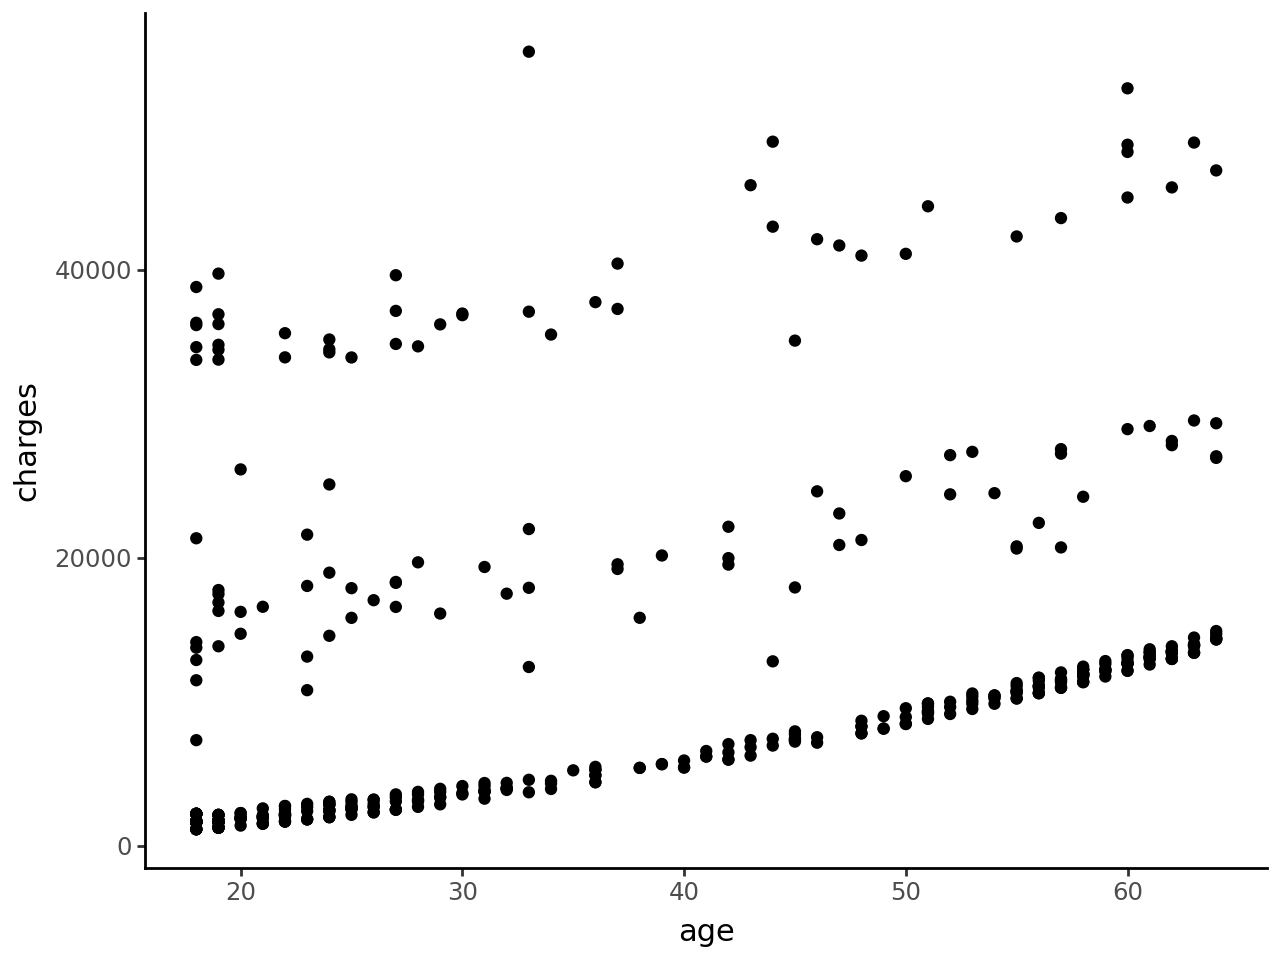

In [7]:
from plotnine import *
plot1 = (ggplot(insur_df, aes(x = "age", y = "charges"))
+ geom_point()
+ theme_classic()
)
plot1

The above plot is a scatterplot that shows us the charges across ages. We can see that charges tend to increase as people get older.

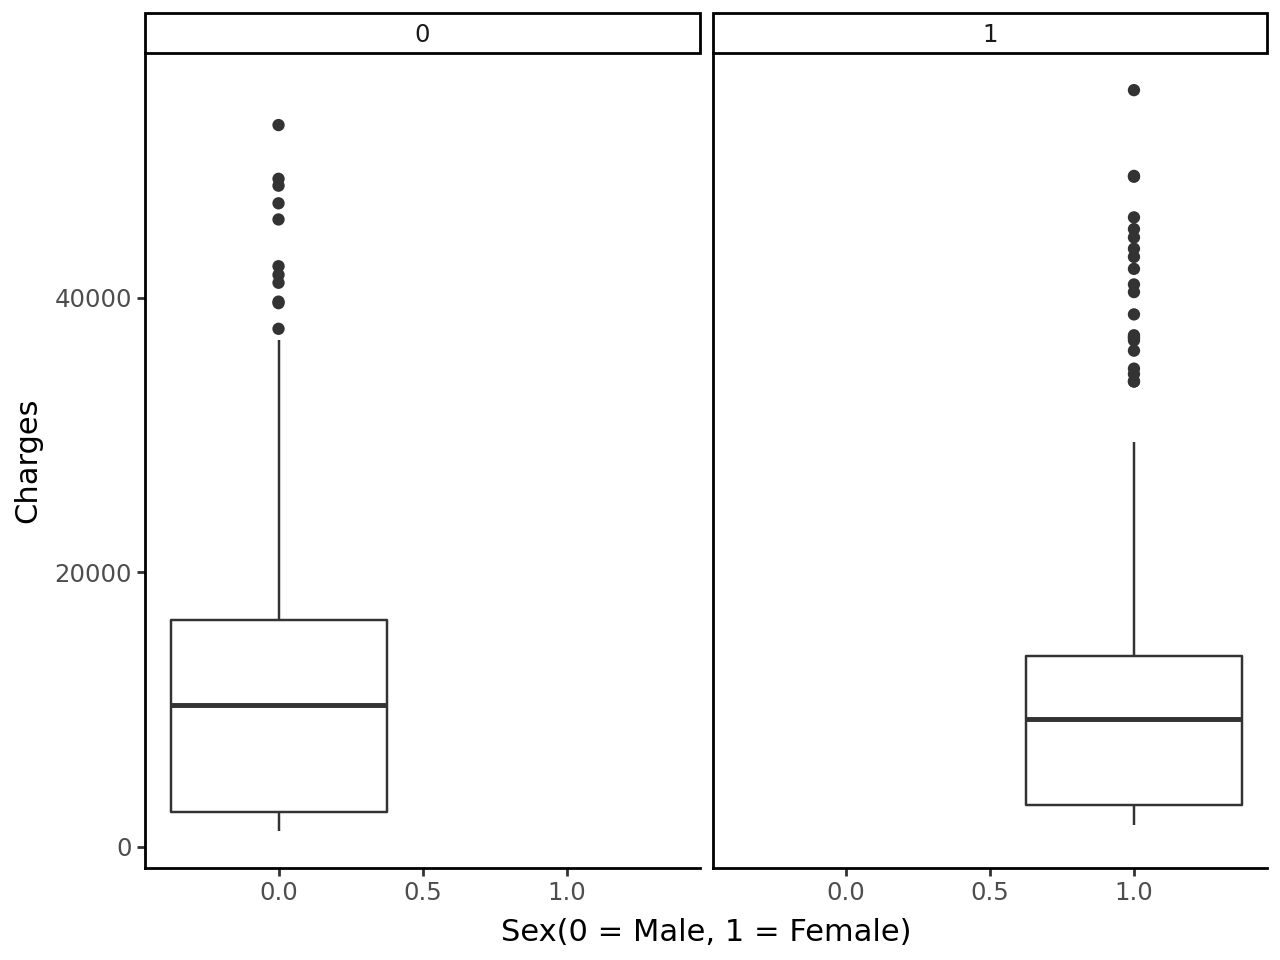

In [8]:
plot2 = (ggplot(insur_df, aes(x = "sex_female", y = "charges"))
+ geom_boxplot()
+ theme_classic()
+facet_wrap("sex_female")
+ labs(x = "Sex(0 = Male, 1 = Female)", y = "Charges")
)
plot2

The above graph is a box plot that shows the difference in charges between males and females. We can see that the median charges for males is slightly higher than for females. However, the maximum charge for females is higher than the males maximum.

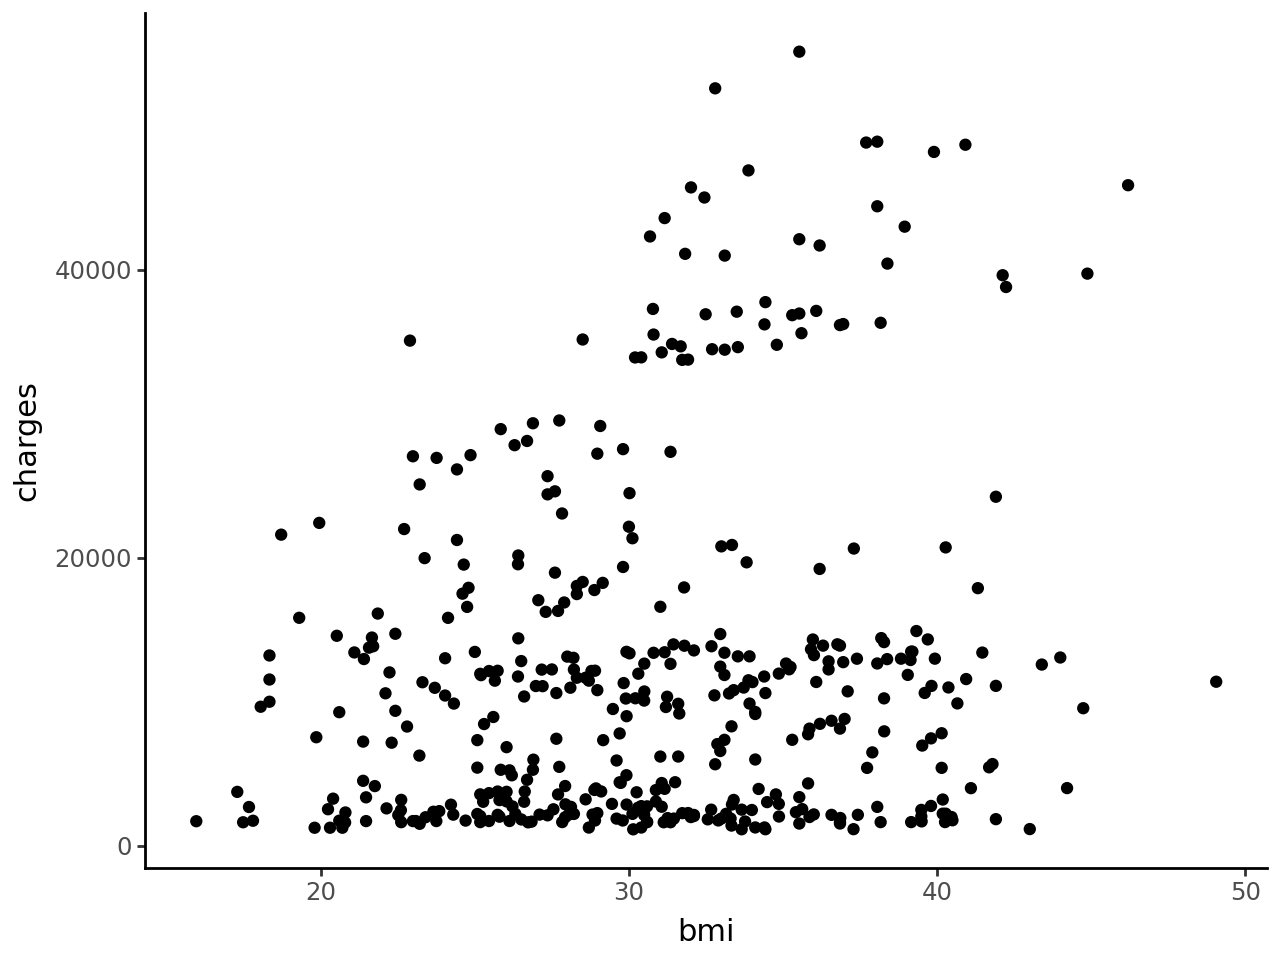

In [9]:
plot3 = (ggplot(insur_df, aes(x = "bmi", y = "charges"))
+ geom_point()
+ theme_classic()
)
plot3

The above graph shows a scatterplot of charges across bmi. We can see that as bmi increases, charges also tend to increase.

## Part 2

In [10]:
# Part 2
# Model with age as predictor
X_train1 = insur_df[["age"]]
y_train = insur_df["charges"]

Model1 = LinearRegression()
Model1.fit(
    X=X_train1,
    y=y_train
)

LinearRegression()

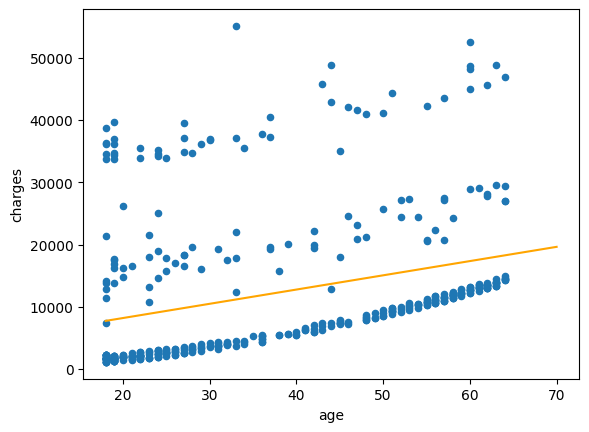

In [11]:
X_new = pd.DataFrame()
X_new["age"] = np.linspace(18, 70, num=1000)
y_new_ = pd.Series(
    Model1.predict(X_new),
    index=X_new["age"]
)

insur_df.plot.scatter(x="age", y="charges")
y_new_.plot.line(c = "orange");

In [12]:
print(Model1.intercept_)
print(Model1.coef_)

3611.758798507106
[228.79904937]


The model does not look like it fits the data well because the points are far away from the least squares regression line, meaning our predictions will be off. The coefficient for age means that for every 1 year increase in age, charges will go up by about 228.80 dollars.

In [13]:
# Model including sex
X_train2 = insur_df[["age","sex_female"]]
y_train = insur_df["charges"]

Model2 = LinearRegression()
Model2.fit(
    X=X_train2,
    y=y_train
)

LinearRegression()

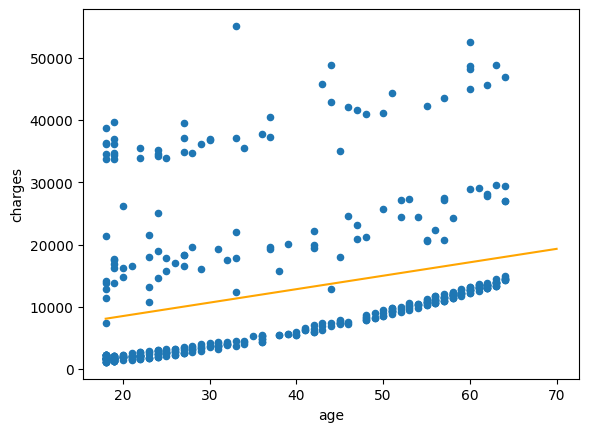

In [14]:
X_new = pd.DataFrame()
X_new["age"] = np.linspace(18, 70, num=1000)
X_new["sex_female"] = np.linspace(0, 1, num=1000)
y_new_ = pd.Series(
    Model2.predict(X_new),
    index=X_new["age"]
)

insur_df.plot.scatter(x="age", y="charges")
y_new_.plot.line(c = "orange");

In [15]:
print(Model2.intercept_)
print(Model2.coef_)

3965.1649365068024
[ 228.42586236 -649.83258997]


In [16]:
# Model with smoker
X_train3 = insur_df[["age","smoker_yes"]]
y_train = insur_df["charges"]

Model3 = LinearRegression()
Model3.fit(
    X=X_train3,
    y=y_train
)

LinearRegression()

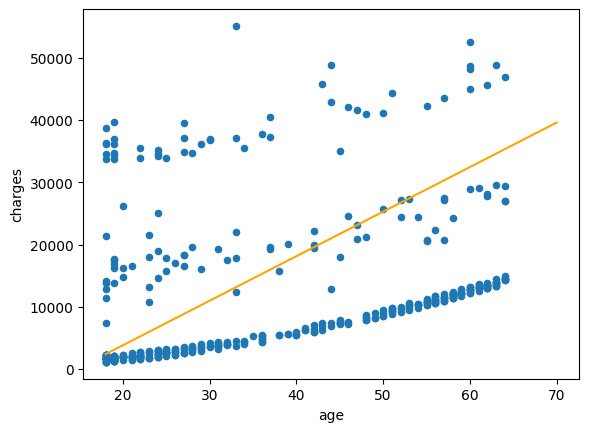

In [17]:
X_new = pd.DataFrame()
X_new["age"] = np.linspace(18, 70, num=1000)
X_new["smoker_yes"] = np.linspace(0, 1, num=1000)
y_new_ = pd.Series(
    Model3.predict(X_new),
    index=X_new["age"]
)

insur_df.plot.scatter(x="age", y="charges")
y_new_.plot.line(c = "orange");

In [18]:
print(Model3.intercept_)
print(Model3.coef_)

-2166.852295375431
[  253.14535549 24048.86743795]


It looks like model 3 would fit the data better since the line goes through more of the points on the graph.

In [19]:
y_train_2 = Model2.predict(X=X_train2)
y_train_3 = Model3.predict(X=X_train3)
insur_df["Model2_pred"] = y_train_2
insur_df["Model3_pred"] = y_train_3
insur_df.head()

,age,bmi,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,Model2_pred,Model3_pred
0,19,27.900,16884.92400,1,0,0,1,0,0,0,1,7655.423731,26691.776897
1,33,22.705,21984.47061,0,1,1,0,0,1,0,0,11503.218394,6186.944436
2,32,28.880,3866.85520,0,1,1,0,0,1,0,0,11274.792532,5933.799080
3,31,25.740,3756.62160,1,0,1,0,0,0,1,0,10396.534080,5680.653725
4,60,25.840,28923.13692,1,0,1,0,0,1,0,0,17020.884088,13021.869034


In [20]:
print("Model 2 MSE:", mean_squared_error(y_train, y_train_2))
print("Model 3 MSE:",mean_squared_error(y_train, y_train_3))
print("Model 2 R-squared:", r2_score(y_train, y_train_2))
print("Model 3 R-squared:", r2_score(y_train, y_train_3))

Model 2 MSE: 126633939.67937087
Model 3 MSE: 33719831.46524373
Model 2 R-squared: 0.10012952499706396
Model 3 R-squared: 0.7603842948069404


Based off of the MSE and R-squared values, model 3 is significantly better than model 2. Model 3 has a lower MSE and 76.04% of the variation in charges is explained by the predictor variables age and smoker.

## Part 3

In [21]:
# Part 3
# Model with age and bmi as predictors
X_train4 = insur_df[["age","bmi"]]
y_train = insur_df["charges"]

Model4 = LinearRegression()
Model4.fit(
    X=X_train4,
    y=y_train
)

LinearRegression()

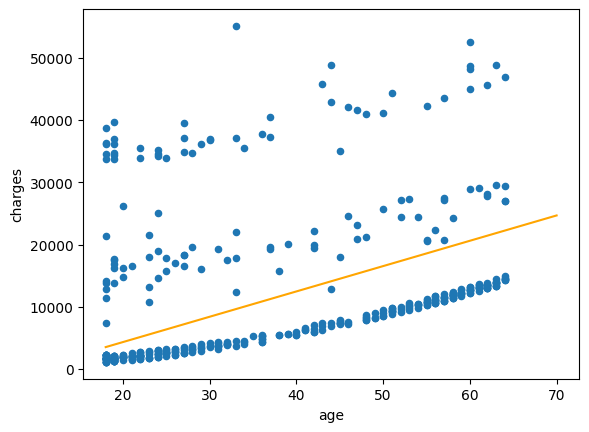

In [22]:
X_new = pd.DataFrame()
X_new["age"] = np.linspace(18, 70, num=1000)
X_new["bmi"] = np.linspace(15, 50, num=1000)
y_new_ = pd.Series(
    Model4.predict(X_new),
    index=X_new["age"]
)

insur_df.plot.scatter(x="age", y="charges")
y_new_.plot.line(c = "orange");

In [23]:
print(Model4.intercept_)
print(Model4.coef_)

-4627.533445708479
[216.29721472 283.20380126]


In [24]:
y_train_1 = Model1.predict(X=X_train1)
insur_df["Model1_pred"] = y_train_1
y_train_4 = Model4.predict(X=X_train4)
insur_df["Model4_pred"] = y_train_4

In [25]:
print("Model 1 MSE:", mean_squared_error(y_train, y_train_1))
print("Model 4 MSE:",mean_squared_error(y_train, y_train_4))
print("Model 1 R-squared:", r2_score(y_train, y_train_1))
print("Model 4 R-squared:", r2_score(y_train, y_train_4))

Model 1 MSE: 126739267.91026388
Model 4 MSE: 123792439.58129103
Model 1 R-squared: 0.09938105452062707
Model 4 R-squared: 0.12032144234129338


The MSE for model 4 is slightly lower and the R-squared is slightly higher, meaning that the model with age and bmi as predictors is slightly better than the model with just age.

In [26]:
# Model with age and age^2
insur_df["age_squared"] = insur_df["age"]**2
X_train5 = insur_df[["age","age_squared"]]
y_train = insur_df["charges"]

Model5 = LinearRegression()
Model5.fit(
    X=X_train5,
    y=y_train
)

LinearRegression()

In [27]:
y_train_5 = Model5.predict(X=X_train5)
insur_df["Model5_pred"] = y_train_5
print("Model 5 MSE:",mean_squared_error(y_train, y_train_5))
print("Model 5 R-squared:",r2_score(y_train, y_train_5))

Model 5 MSE: 126710293.80956802
Model 5 R-squared: 0.09958694669946933


The MSE for the model from part 2 question 1 and this model are almost the same, with the MSE for this model being slightly better. The same can be said for the R-squared values, with this model performing ever so slightly better than the one in part 2 question 1.

In [28]:
# Degree 4 polynomial
insur_df["age_cubed"] = insur_df["age"]**3
insur_df["age_fourth"] = insur_df["age"]**4
X_train6 = insur_df[["age","age_squared","age_cubed","age_fourth"]]
y_train = insur_df["charges"]

Model6 = LinearRegression()
Model6.fit(
    X=X_train6,
    y=y_train
)

LinearRegression()

In [29]:
y_train_6 = Model6.predict(X=X_train6)
insur_df["Model6_pred"] = y_train_6
print("Model 1 MSE:", mean_squared_error(y_train, y_train_1))
print("Model 6 MSE:",mean_squared_error(y_train, y_train_6))
print("Model 1 R-squared:", r2_score(y_train, y_train_1))
print("Model 6 R-squared:",r2_score(y_train, y_train_6))

Model 1 MSE: 126739267.91026388
Model 6 MSE: 125550389.64569846
Model 1 R-squared: 0.09938105452062707
Model 6 R-squared: 0.10782931453183653


The MSE and the R-squared are slightly better than the model in part 2 question 1.

In [30]:
# Degree 12 polynomial
insur_df["age_fifth"] = insur_df["age"]**5
insur_df["age_sixth"] = insur_df["age"]**6
insur_df["age_seventh"] = insur_df["age"]**7
insur_df["age_eighth"] = insur_df["age"]**8
insur_df["age_ninth"] = insur_df["age"]**9
insur_df["age_tenth"] = insur_df["age"]**10
insur_df["age_eleventh"] = insur_df["age"]**11
insur_df["age_twelfth"] = insur_df["age"]**12
X_train7 = insur_df[["age","age_squared","age_cubed","age_fourth","age_fifth","age_sixth","age_seventh","age_eighth","age_ninth","age_tenth","age_eleventh","age_twelfth"]]
y_train = insur_df["charges"]

Model7 = LinearRegression()
Model7.fit(
    X=X_train7,
    y=y_train
)

LinearRegression()

In [31]:
y_train_7 = Model7.predict(X=X_train7)
insur_df["Model7_pred"] = y_train_7
print("Model 1 MSE:", mean_squared_error(y_train, y_train_1))
print("Model 7 MSE:",mean_squared_error(y_train, y_train_7))
print("Model 1 R-squared:", r2_score(y_train, y_train_1))
print("Model 7 R-squared:",r2_score(y_train, y_train_7))

Model 1 MSE: 126739267.91026388
Model 7 MSE: 125373053.69364348
Model 1 R-squared: 0.09938105452062707
Model 7 R-squared: 0.10908947739034713


The MSE and the R-squared of this model are almost the same as the degree 4 polynomial. This model is slightly better than the one in part 2 question 1.

**Part 3 Question 5:**
The best model out of the ones in part 3 appears to be model 4 with age and bmi being the predictor variables. Compared to the other models in part 3, the MSE and R-squared of the model with age and bmi are more of an improvement than we see with the other models.

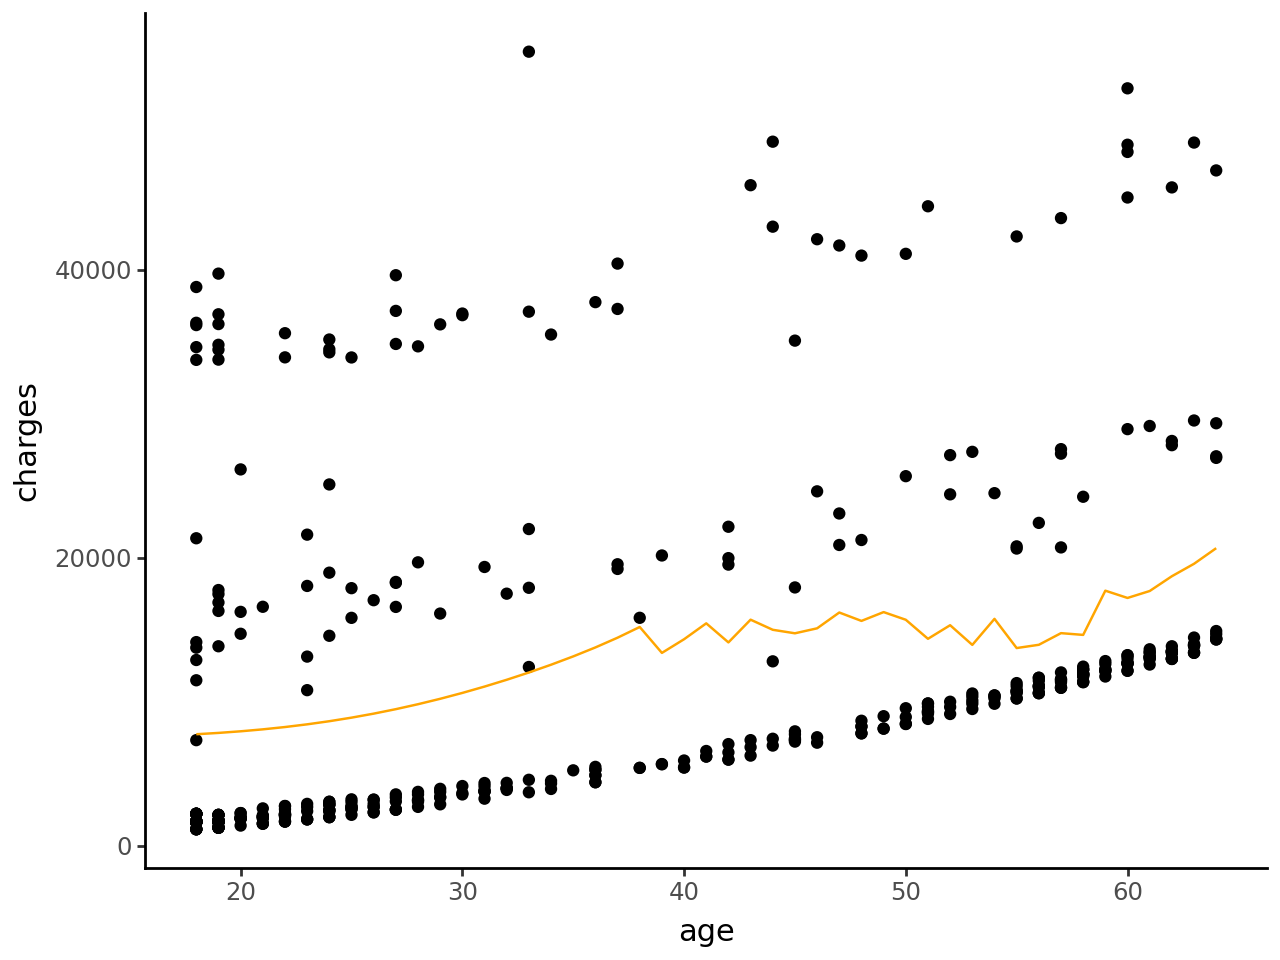

In [35]:
# Plot the predictions from your model in Q4 as a line plot on top of the scatterplot of your original data.
plot4 = (ggplot(insur_df, aes(x = "age", y = "charges"))
+ geom_point()
+ theme_classic()
)

predictions_df = insur_df[["age", "Model7_pred"]]

plot4 = plot4 + geom_line(aes(x = "age", y = "Model7_pred"), color = "orange", data = predictions_df)

plot4

## Part 4

In [40]:
# Part 4
new_data = pd.read_csv("https://www.dropbox.com/s/sky86agc4s8c6qe/insurance_costs_2.csv?dl=1")
new_df = pd.get_dummies(new_data)*1
new_df = new_df.reindex(columns=insur_df.columns, fill_value=0)
y_train = insur_df["charges"]
new_df.head()

,age,bmi,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,...,Model6_pred,age_fifth,age_sixth,age_seventh,age_eighth,age_ninth,age_tenth,age_eleventh,age_twelfth,Model7_pred
0,23,34.400,1826.84300,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,56,40.300,10602.38500,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,18,34.100,1137.01100,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,63,23.085,14451.83515,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,63,28.310,13770.09790,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


MSE for only age as a predictor

In [50]:
# Only age as a predictor
X_train1 = insur_df[["age"]]
X_new1 = new_df[["age"]]
Model1.fit(X_train1, y_train)
pred1 = Model1.predict(X_new1)
mse1 = mean_squared_error(new_df["charges"], pred1)
mse1

136077136.50195494

MSE for age and bmi as predictors

In [45]:
# Age and bmi as predictors
X_train2 = insur_df[["age", "bmi"]]
X_new2 = new_df[["age", "bmi"]]
Model2b = LinearRegression().fit(X_train2, y_train)
pred2 = Model2b.predict(X_new2)
mse2 = mean_squared_error(new_df["charges"], pred2)
mse2

132636406.1108129

MSE for age, bmi, and smoker (no interactions)

In [46]:
# Age, bmi, smoker (no interactions)
X_train3 = insur_df[["age", "bmi", "smoker_yes"]]
X_new3 = new_df[["age", "bmi", "smoker_yes"]]
Model3b = LinearRegression().fit(X_train3, y_train)
pred3 = Model3b.predict(X_new3)
mse3 = mean_squared_error(new_df["charges"], pred3)
mse3

35377541.24141632

MSE for age and bmi with an interaction term with smoker

In [47]:
# Age and bmi with an interaction term with smoker
insur_df["age_smoker"] = insur_df["age"] * insur_df["smoker_yes"]
insur_df["bmi_smoker"] = insur_df["bmi"] * insur_df["smoker_yes"]
new_df["age_smoker"] = new_df["age"] * new_df["smoker_yes"]
new_df["bmi_smoker"] = new_df["bmi"] * new_df["smoker_yes"]

X_train4 = insur_df[["age_smoker", "bmi_smoker"]]
X_new4 = new_df[["age_smoker", "bmi_smoker"]]
Model4b = LinearRegression().fit(X_train4, y_train)
pred4 = Model4b.predict(X_new4)
mse4 = mean_squared_error(new_df["charges"], pred4)
mse4

47626025.35814417

MSE for age, bmi, and smoker as predictors with an interaction term

In [49]:
# Age,bmi and smoker as predictors with an interaction term
X_train5 = insur_df[["age", "bmi", "smoker_yes", "age_smoker", "bmi_smoker"]]
X_new5 = new_df[["age", "bmi", "smoker_yes", "age_smoker", "bmi_smoker"]]
Model5b = LinearRegression().fit(X_train5, y_train)
pred5 = Model5b.predict(X_new5)
mse5 = mean_squared_error(new_df["charges"], pred5)
mse5

21786256.86685252

The best model to use would be the last one with age, bmi, and smoker as predictors with both quantitative variables having an interaction term with smoker because this model has the lowest MSE out of the ones we tested.

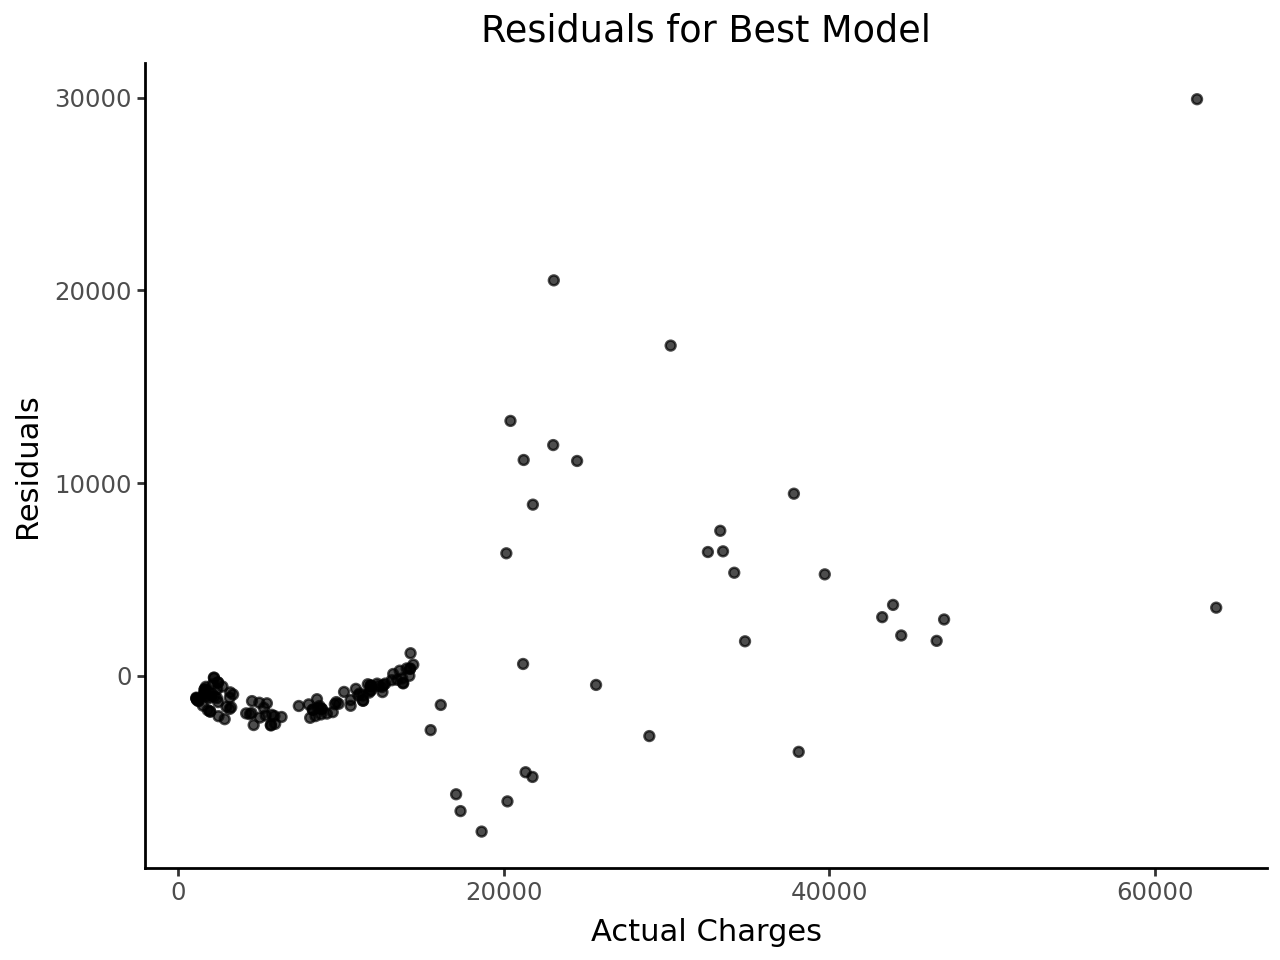

In [53]:
# Plot with residuals for the final chosen model
residuals = new_df["charges"] - pred5
resid_df = pd.DataFrame({
    "actual": new_df["charges"],
    "residual": residuals
})

plot5 = (
    ggplot(resid_df, aes(x="actual", y="residual"))
    + geom_point(alpha=0.7)
    + labs(
        x="Actual Charges",
        y="Residuals",
        title=f"Residuals for Best Model"
      )
    + theme_classic()
)
plot5

## Part 5

In [84]:
# Part 5
from sklearn.preprocessing import PolynomialFeatures

predictors = ["age", "bmi", "smoker_yes"]
degree = 2

X_train = insur_df[predictors]
y_train = insur_df["charges"]
X_test = new_df[predictors]
y_test = new_df["charges"]

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

best_model = LinearRegression()
best_model.fit(X_train_poly, y_train)

LinearRegression()

In [85]:
y_pred = best_model.predict(X_test_poly)
best_model_mse = mean_squared_error(y_test, y_pred)
best_model_r2 = r2_score(y_test, y_pred)
print("MSE:",best_model_mse)
print("R-squared",best_model_r2)

MSE: 21532023.680487297
R-squared 0.8611283665034096


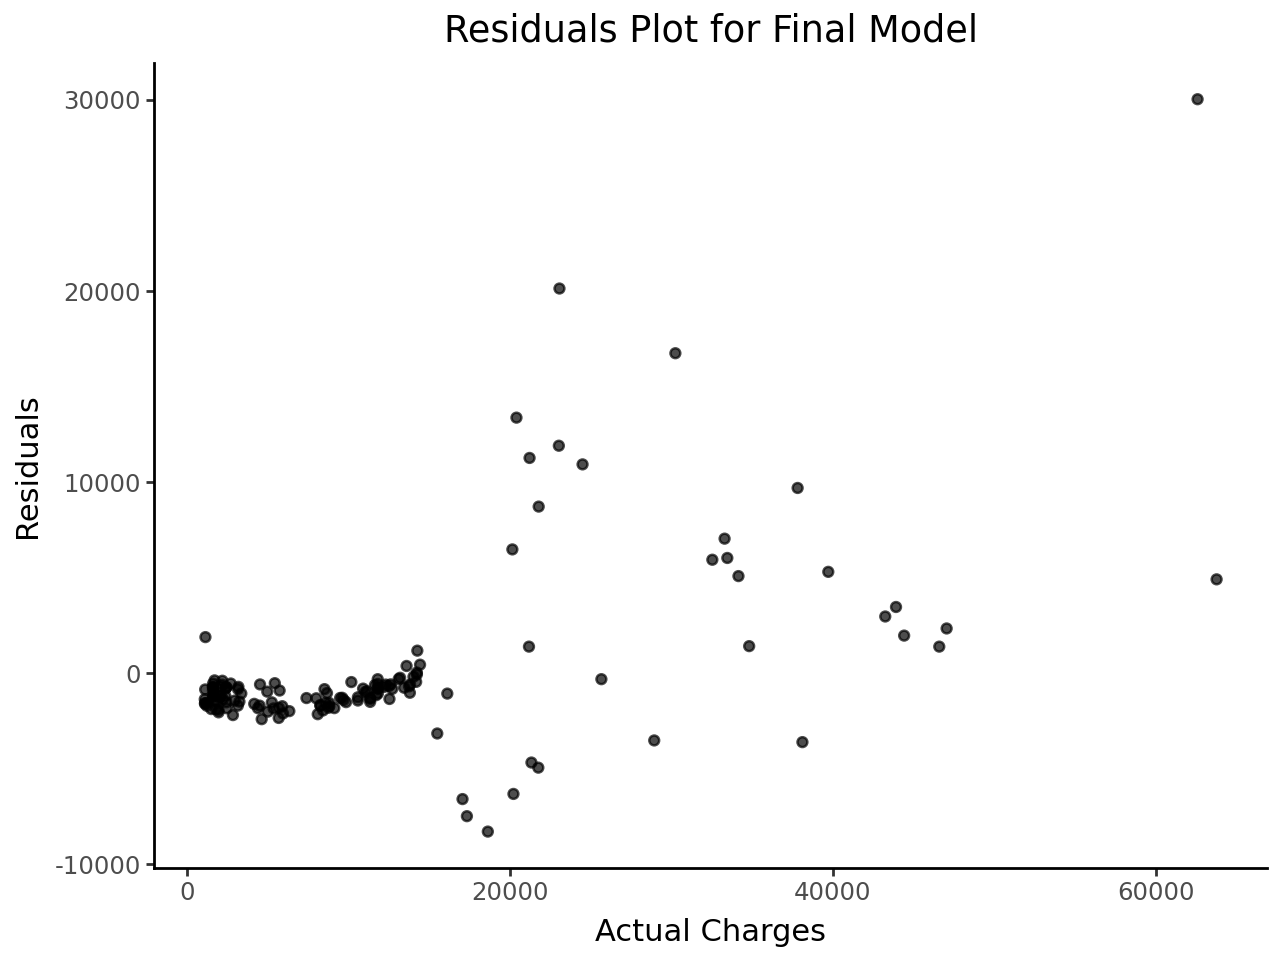

In [86]:
# Plot with residuals of final model
residuals = pd.DataFrame({"actual": y_test, "residual": y_test - y_pred})
plot6 = (
    ggplot(residuals, aes(x="actual", y="residual"))
    + geom_point(alpha=0.7)
    + labs(
        x="Actual Charges",
        y="Residuals",
        title=f"Residuals Plot for Final Model",
    )
    + theme_classic()
)
plot6

The model that I found to be the best was a simple one that included age, bmi, and smoker as the predictor variables. This lead to a MSE of 21532023 and an R-squared value of 0.8611, meaning that 86.11% of the variation in the response is explained by the three predictor variables included in the model.